# 1. Preprocessing

## a. Data load and check
Memeriksa informasi-informasi awal dari data

In [458]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [459]:
df = pd.DataFrame(pd.read_csv("Student_Mental_health.csv"))
df

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,13/07/2020 21:21:42,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,13/07/2020 21:23:57,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


In [460]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    str    
 1   Choose your gender                            101 non-null    str    
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    str    
 4   Your current year of Study                    101 non-null    str    
 5   What is your CGPA?                            101 non-null    str    
 6   Marital status                                101 non-null    str    
 7   Do you have Depression?                       101 non-null    str    
 8   Do you have Anxiety?                          101 non-null    str    
 9   Do you have Panic attack?                     101 non-null    str    
 10  D

In [461]:
df.duplicated().sum()

np.int64(0)

## b. Data Cleaning
Isinya bersih bersih data, kaya hapus data ga penting, fill data NaN

In [462]:
df.columns = ['Timestamp','Gender','Age','Course','Year','CGPA',
              'Marital','Depression','Anxiety','Panic','Treatment']
df['Course'] = df['Course'].str.strip()

In [463]:
df.drop("Timestamp", axis=1, inplace=True)
df

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment
0,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


In [464]:
df["Gender"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [465]:
df['Year'] = df['Year'].str.replace('year', '', case=False).str.strip().astype(int)

In [466]:
# Mencari baris yang memiliki nilai NaN pada kolom Age
df[df['Age'].isna()]

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment
43,Male,NaN,BIT,1,0 - 1.99,No,No,No,No,No


In [467]:
print(df[df["Year"] == 1]["Age"].median())
df['Age'] = df['Age'].fillna(df[df["Year"] == 1]["Age"].median())

19.0


In [468]:
print(df.isna().sum())

Gender        0
Age           0
Course        0
Year          0
CGPA          0
Marital       0
Depression    0
Anxiety       0
Panic         0
Treatment     0
dtype: int64


In [469]:
df['CGPA'].unique()

<StringArray>
[ '3.00 - 3.49',  '3.50 - 4.00', '3.50 - 4.00 ',  '2.50 - 2.99',
  '2.00 - 2.49',     '0 - 1.99']
Length: 6, dtype: str

In [470]:
df['CGPA'] = df['CGPA'].str.strip()

In [471]:
df['CGPA'].unique()

<StringArray>
['3.00 - 3.49', '3.50 - 4.00', '2.50 - 2.99', '2.00 - 2.49', '0 - 1.99']
Length: 5, dtype: str

## c. EDA
Liat liat dulu statistik datanya

In [472]:
sns.set_theme(style="whitegrid")
MENTAL_COLS = ['Depression', 'Anxiety', 'Panic']

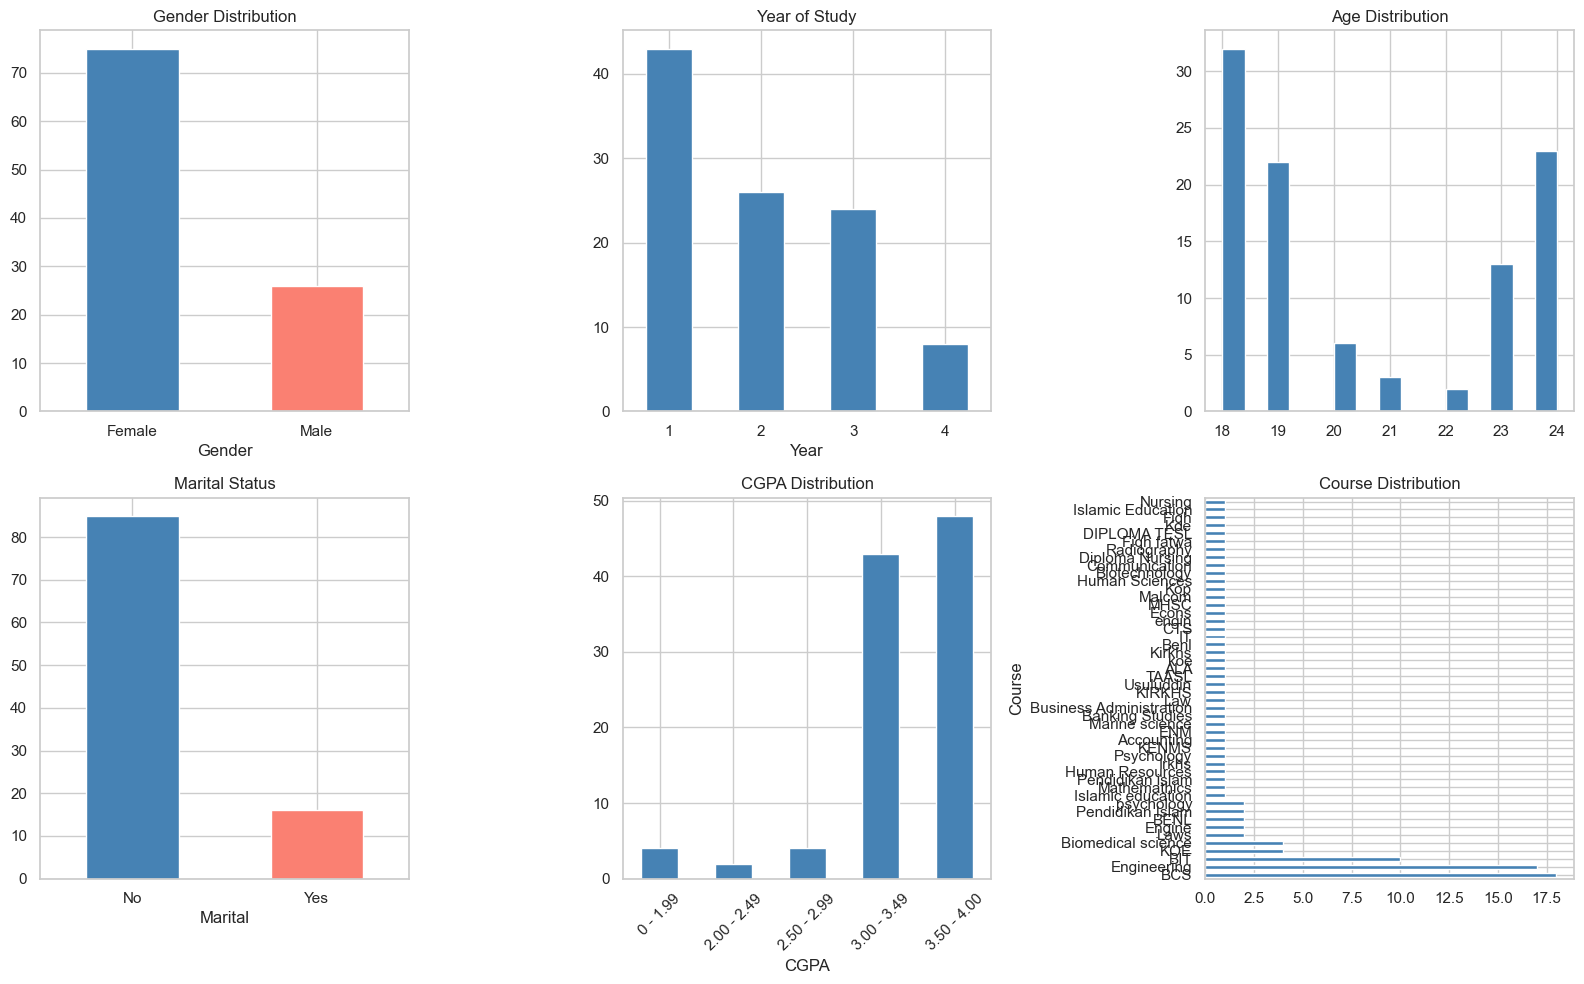

In [473]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Gender
df['Gender'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','salmon'])
axes[0,0].set_title('Gender Distribution')
axes[0,0].tick_params(axis='x', rotation=0)

# Year
df['Year'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Year of Study')
axes[0,1].tick_params(axis='x', rotation=0)

# Age
axes[0,2].hist(df['Age'], bins=15, color='steelblue', edgecolor='white')
axes[0,2].set_title('Age Distribution')

# Marital Status
df['Marital'].value_counts().plot(kind='bar', ax=axes[1,0], color=['steelblue','salmon'])
axes[1,0].set_title('Marital Status')
axes[1,0].tick_params(axis='x', rotation=0)

# CGPA
df['CGPA'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('CGPA Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

# Course
df['Course'].value_counts().plot(kind='barh', ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Course Distribution')

plt.tight_layout()
plt.show()

Insights:
- Female jauh lebih banyak yang ngisi. Ada kemungkinan modelnya bias dan lebih apal pola female.
- Mahasiswa tahun awal lebih sering ngisi.
- Pola age bentuknya kaya parabola, gede di awal dan akhir, di tengah dikit.
- Dikit banget yang nikah. Bisa dilihat nanti apakah yang nikah memiliki relation yang kuat ke kondisi tertentu.
- CGPA banyak yang di atas 3.00. Sedikit yang ada di bawah 2.99, memungkinkan untuk binning.
- Course terlalu sparse, cluttered banget, asli. Nanti di grouping dah mending.


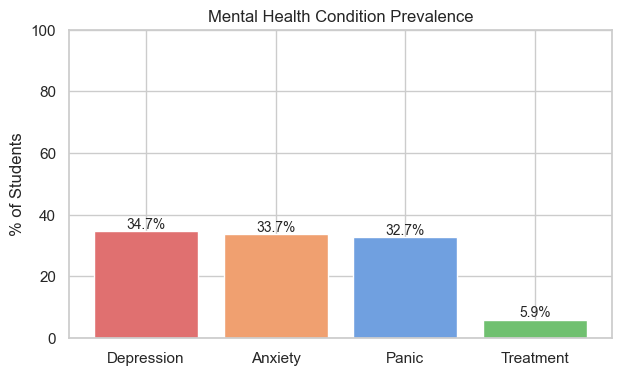

In [474]:
prevalence = df[MENTAL_COLS + ['Treatment']].apply(lambda col: (col == 'Yes').mean() * 100)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(prevalence.index, prevalence.values, color=['#e07070','#f0a070','#70a0e0','#70c070'])
ax.set_ylabel('% of Students')
ax.set_title('Mental Health Condition Prevalence')
ax.set_ylim(0, 100)

for bar, val in zip(bars, prevalence.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10)

plt.show()

Lumayan rata, dan yang treatment dikit, menarik. Bisa diolah nanti

In [475]:
mental_binary = df[MENTAL_COLS].apply(lambda col: (col == 'Yes').astype(int))
combos = mental_binary.groupby(MENTAL_COLS).size().reset_index(name='Count').sort_values('Count', ascending=False)
print(combos.to_string(index=False))

 Depression  Anxiety  Panic  Count
          0        0      0     37
          0        0      1     13
          0        1      0     13
          1        0      0     10
          1        1      1     10
          1        1      0      8
          1        0      1      7
          0        1      1      3


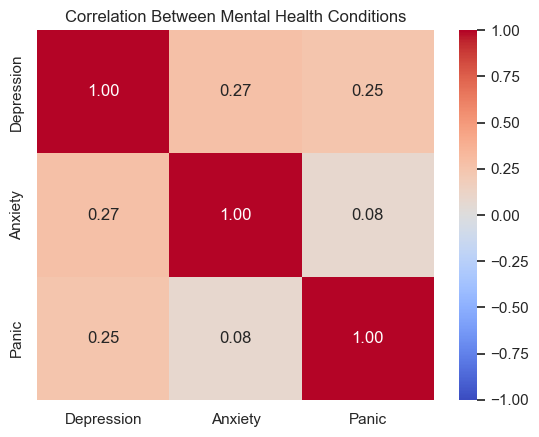

In [476]:
corr = mental_binary.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Mental Health Conditions')
plt.show()

Menarik, ga terlalu ada keterkaitan mutlak satu sama lain, mungkin nanti bisa diambil insightnya.

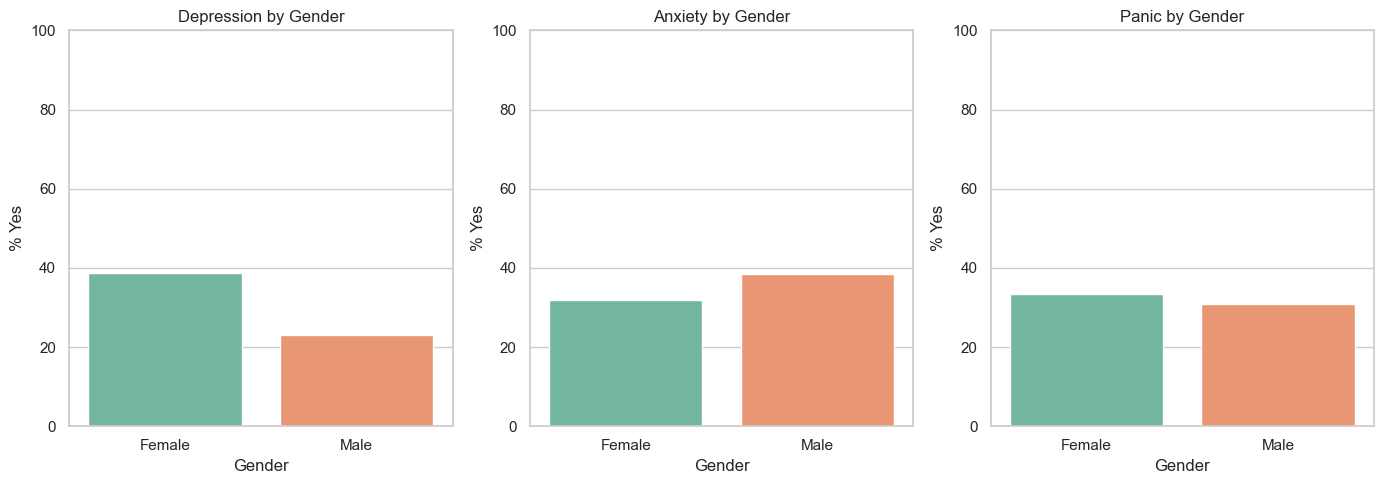

In [477]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('Gender')[col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    ct.columns = ['Gender', 'Pct']
    sns.barplot(data=ct, x='Gender', y='Pct', ax=ax, palette='Set2')
    ax.set_title(f'{col} by Gender')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Tidak ada dominasi atau kecenderungan mutlak dari gender terhadap keadaan mental.

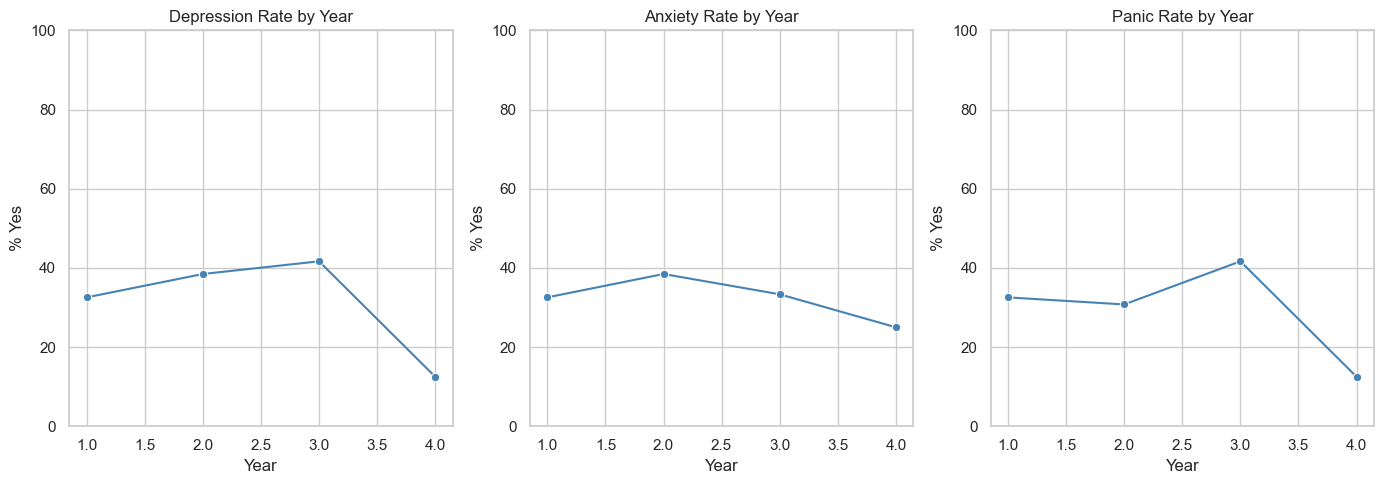

In [478]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('Year')[col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    ct.columns = ['Year', 'Pct']
    sns.lineplot(data=ct, x='Year', y='Pct', ax=ax, marker='o', color='steelblue')
    ax.set_title(f'{col} Rate by Year')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Terlihat depresi dan panic rate paling tinggi ada di tahun ke 3, dan anxiety di tahun ke 2.

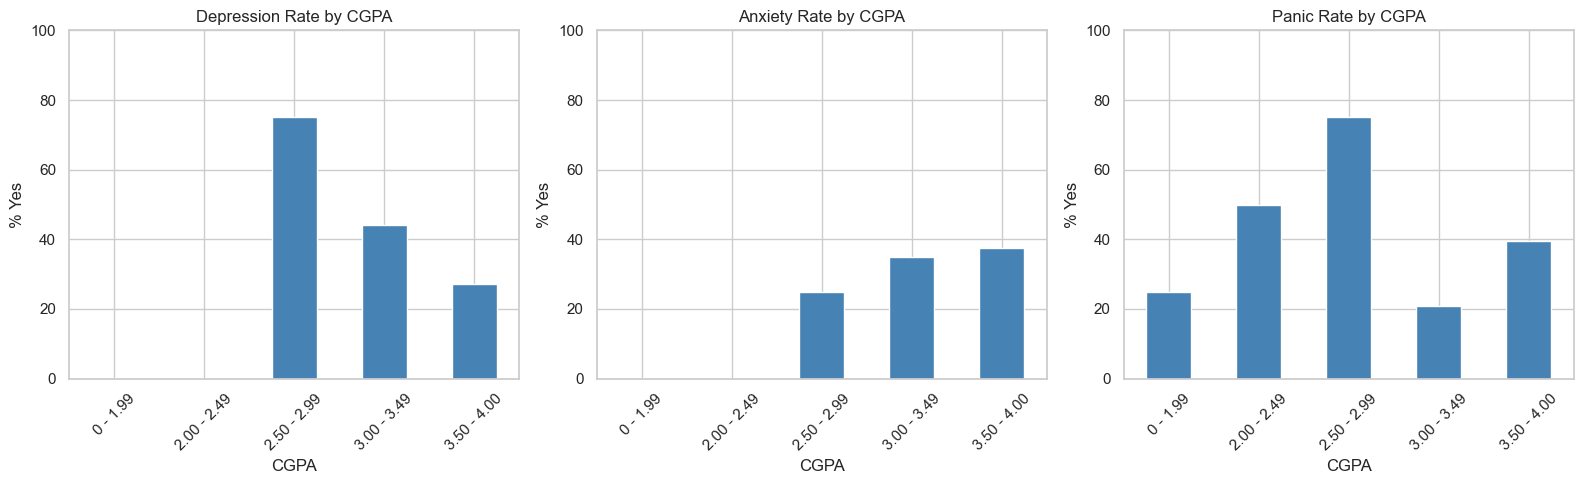

In [479]:
cgpa_order = sorted(df['CGPA'].unique())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('CGPA')[col].apply(lambda x: (x == 'Yes').mean() * 100).reindex(cgpa_order)
    ct.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{col} Rate by CGPA')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Tren dari setiap kondisi mental berbeda-beda jika dilihat berdasarkan CGPA. Depression rate memiliki tren yang menurun mulai dari 2.5. Anxiety memiliki tren naik. Panic rate tidak terlalu memiliki tren yang jelas, namun mahasiswa dengan CGPA yang rendah memiliki kondisi Panic.

In [480]:
df['Any_condition'] = df[MENTAL_COLS].apply(lambda row: 'Yes' in row.values, axis=1)

ct = pd.crosstab(df['Any_condition'], df['Treatment'])
ct.index = ['No Condition', 'Has Condition']
ct.columns = ['No Treatment', 'Seeking Treatment']
print(ct)
print()
print("Of students WITH a condition, % seeking treatment:",
      round(ct.loc['Has Condition', 'Seeking Treatment'] / ct.loc['Has Condition'].sum() * 100, 1), "%")

               No Treatment  Seeking Treatment
No Condition             37                  0
Has Condition            58                  6

Of students WITH a condition, % seeking treatment: 9.4 %


Uih, SANGAT sedikit mahasiswa dengan setidaknya satu kondisi mental yang mencari pertolongan profesional

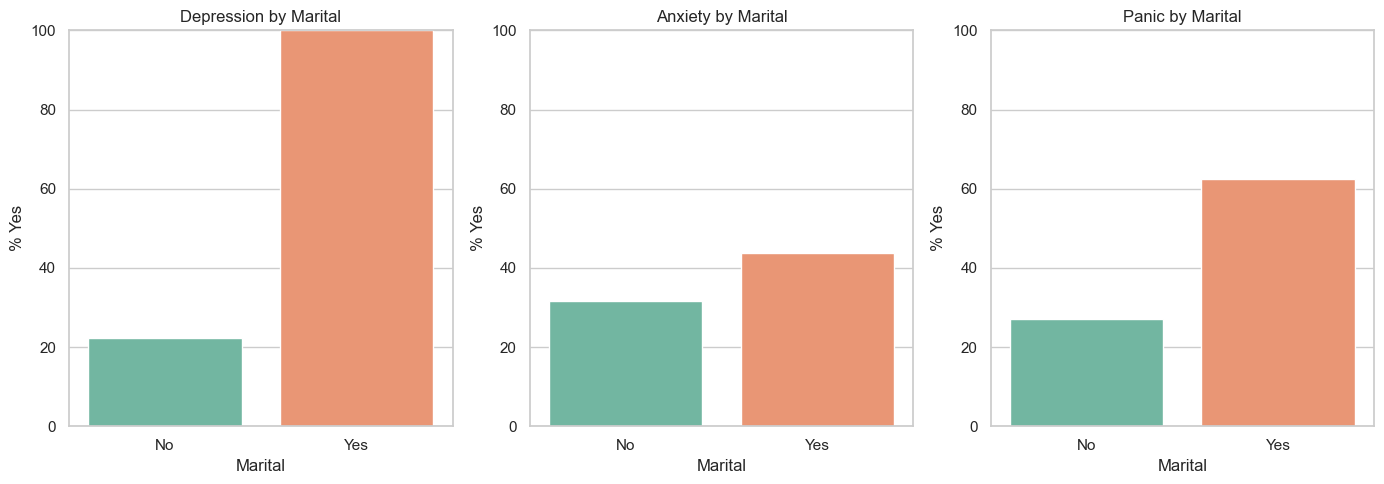

In [481]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('Marital')[col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    ct.columns = ['Marital', 'Pct']
    sns.barplot(data=ct, x='Marital', y='Pct', ax=ax, palette='Set2')
    ax.set_title(f'{col} by Marital')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [482]:
df[df["Marital"] == "Yes"]

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment,Any_condition
3,Female,22.0,Laws,3,3.00 - 3.49,Yes,Yes,No,No,No,True
6,Female,23.0,Pendidikan islam,2,3.50 - 4.00,Yes,Yes,No,Yes,No,True
11,Female,24.0,Engineering,3,3.50 - 4.00,Yes,Yes,No,No,No,True
17,Female,24.0,ENM,4,3.00 - 3.49,Yes,Yes,Yes,Yes,No,True
19,Female,18.0,Marine science,2,3.50 - 4.00,Yes,Yes,Yes,Yes,No,True
27,Male,18.0,Engineering,2,3.00 - 3.49,Yes,Yes,Yes,No,No,True
28,Female,24.0,BIT,3,3.50 - 4.00,Yes,Yes,Yes,Yes,Yes,True
33,Male,18.0,BCS,2,3.50 - 4.00,Yes,Yes,Yes,No,Yes,True
39,Female,24.0,Engineering,2,2.50 - 2.99,Yes,Yes,No,Yes,Yes,True
50,Female,23.0,ALA,1,2.50 - 2.99,Yes,Yes,No,Yes,Yes,True


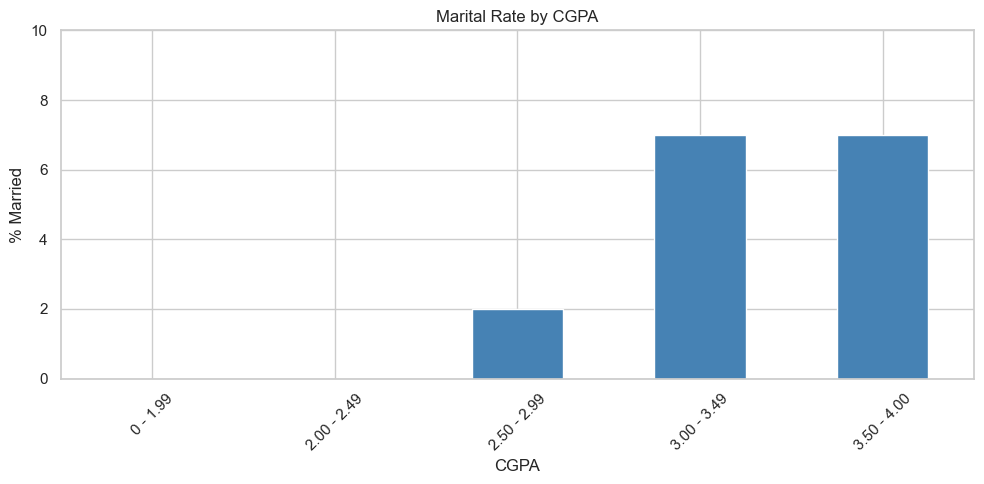

In [483]:
cgpa_order = sorted(df['CGPA'].unique())

fig, ax = plt.subplots(figsize=(10, 5))

ct = (
    df.groupby('CGPA')['Marital']
    .apply(lambda x: (x == 'Yes').sum())
    .reindex(cgpa_order)
)

ct.plot(kind='bar', ax=ax, color='steelblue')

ax.set_title('Marital Rate by CGPA')
ax.set_ylabel('% Married')
ax.set_xlabel('CGPA')
ax.set_ylim(0, 10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

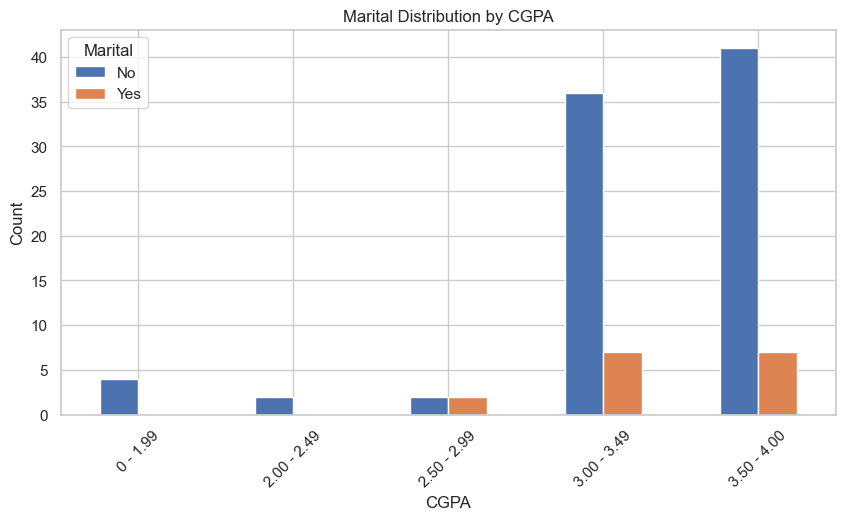

In [484]:
pd.crosstab(df['CGPA'], df['Marital']).reindex(cgpa_order).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Marital Distribution by CGPA')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Dari sini, kita bisa lihat bahwa orang yang menikah berada di rentang CGPA 2.5-4.00 dengan tren naik, yang mana sama dengan tren seluruh mahasiswa secara general. Tidak ada insight yang berarti yang dapat diambil disini.

In [485]:
df

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment,Any_condition
0,Female,18.0,Engineering,1,3.00 - 3.49,No,Yes,No,Yes,No,True
1,Male,21.0,Islamic education,2,3.00 - 3.49,No,No,Yes,No,No,True
2,Male,19.0,BIT,1,3.00 - 3.49,No,Yes,Yes,Yes,No,True
3,Female,22.0,Laws,3,3.00 - 3.49,Yes,Yes,No,No,No,True
4,Male,23.0,Mathemathics,4,3.00 - 3.49,No,No,No,No,No,False
...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,BCS,1,3.50 - 4.00,No,No,Yes,No,No,True
97,Male,18.0,Engineering,2,3.00 - 3.49,No,Yes,Yes,No,No,True
98,Female,19.0,Nursing,3,3.50 - 4.00,Yes,Yes,No,Yes,No,True
99,Female,23.0,Pendidikan Islam,4,3.50 - 4.00,No,No,No,No,No,False


## d. Feature Engineering
Mulai otak-atik fitur, misal grouping, dll.

In [486]:
df['Course'].unique()

<StringArray>
[            'Engineering',       'Islamic education',
                     'BIT',                    'Laws',
            'Mathemathics',        'Pendidikan islam',
                     'BCS',         'Human Resources',
                   'Irkhs',              'Psychology',
                   'KENMS',              'Accounting',
                     'ENM',          'Marine science',
                     'KOE',         'Banking Studies',
 'Business Administration',                     'Law',
                  'KIRKHS',               'Usuluddin',
                   'TAASL',                  'Engine',
                     'ALA',      'Biomedical science',
                     'koe',                  'Kirkhs',
                    'BENL',                    'Benl',
                      'IT',                     'CTS',
                   'engin',                   'Econs',
                    'MHSC',                  'Malcom',
                     'Kop',          'Human Science

In [487]:
course_clean_mapping = {
    'Engineering'           : 'Engineering',
    'Engine'                : 'Engineering',
    'engin'                 : 'Engineering',
    'KOE'                   : 'Engineering',
    'koe'                   : 'Engineering',
    'Koe'                   : 'Engineering',
    'BCS'                   : 'BCS',
    'BIT'                   : 'BIT',
    'IT'                    : 'BIT',
    'CTS'                   : 'BIT',
    'Biomedical science'    : 'Biomedical Science',
    'Biotechnology'         : 'Biotechnology',
    'Mathemathics'          : 'Mathematics',
    'Marine science'        : 'Marine Science',
    'Islamic education'     : 'Islamic Education',
    'Islamic Education'     : 'Islamic Education',
    'Pendidikan islam'      : 'Islamic Education',
    'Pendidikan Islam'      : 'Islamic Education',
    'Irkhs'                 : 'Islamic Education',
    'KIRKHS'                : 'Islamic Education',
    'Kirkhs'                : 'Islamic Education',
    'Fiqh fatwa'            : 'Islamic Education',
    'Fiqh'                  : 'Islamic Education',
    'Usuluddin'             : 'Islamic Education',
    'MHSC'                  : 'Islamic Education',
    'Malcom'                : 'Islamic Education',
    'BENL'                  : 'English Language',
    'Benl'                  : 'English Language',
    'TAASL'                 : 'English Language',
    'ALA'                   : 'English Language',
    'DIPLOMA TESL'          : 'English Language',
    'Human Resources'       : 'Human Sciences',
    'Human Sciences'        : 'Human Sciences',
    'Psychology'            : 'Psychology',
    'psychology'            : 'Psychology',
    'Laws'                  : 'Law',
    'Law'                   : 'Law',
    'Nursing'               : 'Nursing',
    'Diploma Nursing'       : 'Nursing',
    'Radiography'           : 'Radiography',
    'Communication'         : 'Communication',
    'Econs'                 : 'Economics',
    'ENM'                   : 'Economics',
    'KENMS'                 : 'Economics',
    'Business Administration': 'Business Administration',
    'Banking Studies'       : 'Banking Studies',
    'Accounting'            : 'Accounting',
    'Kop'                   : 'Pharmacy',
}

In [488]:
rumpun_mapping = {

    # Computing & Engineering
    'Engineering'        : 'Engineering & Computing',
    'BCS'                : 'Engineering & Computing',
    'BIT'                : 'Engineering & Computing',

    # Natural & Health Sciences
    'Biomedical Science' : 'Natural & Health Sciences',
    'Biotechnology'      : 'Natural & Health Sciences',
    'Marine Science'     : 'Natural & Health Sciences',
    'Pharmacy'           : 'Natural & Health Sciences',
    'Mathematics'        : 'Natural & Health Sciences',
    'Nursing'            : 'Natural & Health Sciences',
    'Radiography'        : 'Natural & Health Sciences',

    # Social Sciences
    'Psychology'             : 'Social Sciences',
    'Human Sciences'         : 'Social Sciences',
    'Economics'              : 'Social Sciences',
    'Business Administration': 'Social Sciences',
    'Banking Studies'        : 'Social Sciences',
    'Accounting'             : 'Social Sciences',
    'Communication'          : 'Social Sciences',

    # Humanities & Education
    'Islamic Education'  : 'Humanities & Education',
    'English Language'   : 'Humanities & Education',
    'Law'                : 'Humanities & Education',
}

In [489]:
df['Course_clean'] = df['Course'].map(course_clean_mapping)
df['Course_group'] = df['Course_clean'].map(rumpun_mapping)

In [490]:
unmapped = df[df['Course_group'].isna()]['Course'].unique()
if len(unmapped) > 0:
    print("Unmapped:", unmapped)
else:
    print("Mapping ok")

Mapping ok


In [491]:
print("Detail Mapping")
detail = df.groupby('Course_group')['Course_clean'].apply(lambda x: sorted(x.unique())).reset_index()
for _, row in detail.iterrows():
    print(f"\n  [{row['Course_group']}]")
    for c in row['Course_clean']:
        print(f"    - {c}")
 
print("\n=== DISTRIBUSI FINAL ===")
dist = df['Course_group'].value_counts()
for group, count in dist.items():
    bar = '█' * count
    pct = count / len(df) * 100
    print(f"  {group:<25} {count:>3} ({pct:4.1f}%)  {bar}")

Detail Mapping

  [Engineering & Computing]
    - BCS
    - BIT
    - Engineering

  [Humanities & Education]
    - English Language
    - Islamic Education
    - Law

  [Natural & Health Sciences]
    - Biomedical Science
    - Biotechnology
    - Marine Science
    - Mathematics
    - Nursing
    - Pharmacy
    - Radiography

  [Social Sciences]
    - Accounting
    - Banking Studies
    - Business Administration
    - Communication
    - Economics
    - Human Sciences
    - Psychology

=== DISTRIBUSI FINAL ===
  Engineering & Computing    56 (55.4%)  ████████████████████████████████████████████████████████
  Humanities & Education     22 (21.8%)  ██████████████████████
  Social Sciences            12 (11.9%)  ████████████
  Natural & Health Sciences  11 (10.9%)  ███████████


In [492]:
def risk_level(row):
    score = (row['Depression']=='Yes') + (row['Anxiety']=='Yes') + (row['Panic']=='Yes')
    if score == 0: return 'Low'
    elif score == 1: return 'Medium'
    else: return 'High'
    
df['Risk_Level'] = df.apply(risk_level, axis=1)
 
print("\nRisk Level Per Rumpun")
ct = pd.crosstab(df['Course_group'], df['Risk_Level'])
ct['Total'] = ct.sum(axis=1)
ct['High%'] = (ct.get('High', 0) / ct['Total'] * 100).round(1)
print(ct.to_string())


Risk Level Per Rumpun
Risk_Level                 High  Low  Medium  Total  High%
Course_group                                              
Engineering & Computing      15   17      24     56   26.8
Humanities & Education        6    7       9     22   27.3
Natural & Health Sciences     2    8       1     11   18.2
Social Sciences               5    5       2     12   41.7


In [493]:
df

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment,Any_condition,Course_clean,Course_group,Risk_Level
0,Female,18.0,Engineering,1,3.00 - 3.49,No,Yes,No,Yes,No,True,Engineering,Engineering & Computing,High
1,Male,21.0,Islamic education,2,3.00 - 3.49,No,No,Yes,No,No,True,Islamic Education,Humanities & Education,Medium
2,Male,19.0,BIT,1,3.00 - 3.49,No,Yes,Yes,Yes,No,True,BIT,Engineering & Computing,High
3,Female,22.0,Laws,3,3.00 - 3.49,Yes,Yes,No,No,No,True,Law,Humanities & Education,Medium
4,Male,23.0,Mathemathics,4,3.00 - 3.49,No,No,No,No,No,False,Mathematics,Natural & Health Sciences,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,BCS,1,3.50 - 4.00,No,No,Yes,No,No,True,BCS,Engineering & Computing,Medium
97,Male,18.0,Engineering,2,3.00 - 3.49,No,Yes,Yes,No,No,True,Engineering,Engineering & Computing,High
98,Female,19.0,Nursing,3,3.50 - 4.00,Yes,Yes,No,Yes,No,True,Nursing,Natural & Health Sciences,High
99,Female,23.0,Pendidikan Islam,4,3.50 - 4.00,No,No,No,No,No,False,Islamic Education,Humanities & Education,Low


In [494]:
df.drop(['Course', 'Depression', 'Anxiety', 'Panic'], axis=1, inplace=True)
df.rename(columns={'Course_clean': 'Course'}, inplace=True)

In [495]:
df

,Gender,Age,Year,CGPA,Marital,Treatment,Any_condition,Course,Course_group,Risk_Level
0,Female,18.0,1,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High
1,Male,21.0,2,3.00 - 3.49,No,No,True,Islamic Education,Humanities & Education,Medium
2,Male,19.0,1,3.00 - 3.49,No,No,True,BIT,Engineering & Computing,High
3,Female,22.0,3,3.00 - 3.49,Yes,No,True,Law,Humanities & Education,Medium
4,Male,23.0,4,3.00 - 3.49,No,No,False,Mathematics,Natural & Health Sciences,Low
...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,1,3.50 - 4.00,No,No,True,BCS,Engineering & Computing,Medium
97,Male,18.0,2,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High
98,Female,19.0,3,3.50 - 4.00,Yes,No,True,Nursing,Natural & Health Sciences,High
99,Female,23.0,4,3.50 - 4.00,No,No,False,Islamic Education,Humanities & Education,Low


In [496]:
df['Silent_Sufferer'] = ((df['Any_condition'] == True) & (df['Treatment'] == 'No'))
df

,Gender,Age,Year,CGPA,Marital,Treatment,Any_condition,Course,Course_group,Risk_Level,Silent_Sufferer
0,Female,18.0,1,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High,True
1,Male,21.0,2,3.00 - 3.49,No,No,True,Islamic Education,Humanities & Education,Medium,True
2,Male,19.0,1,3.00 - 3.49,No,No,True,BIT,Engineering & Computing,High,True
3,Female,22.0,3,3.00 - 3.49,Yes,No,True,Law,Humanities & Education,Medium,True
4,Male,23.0,4,3.00 - 3.49,No,No,False,Mathematics,Natural & Health Sciences,Low,False
...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,1,3.50 - 4.00,No,No,True,BCS,Engineering & Computing,Medium,True
97,Male,18.0,2,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High,True
98,Female,19.0,3,3.50 - 4.00,Yes,No,True,Nursing,Natural & Health Sciences,High,True
99,Female,23.0,4,3.50 - 4.00,No,No,False,Islamic Education,Humanities & Education,Low,False


<function matplotlib.pyplot.show(close=None, block=None)>

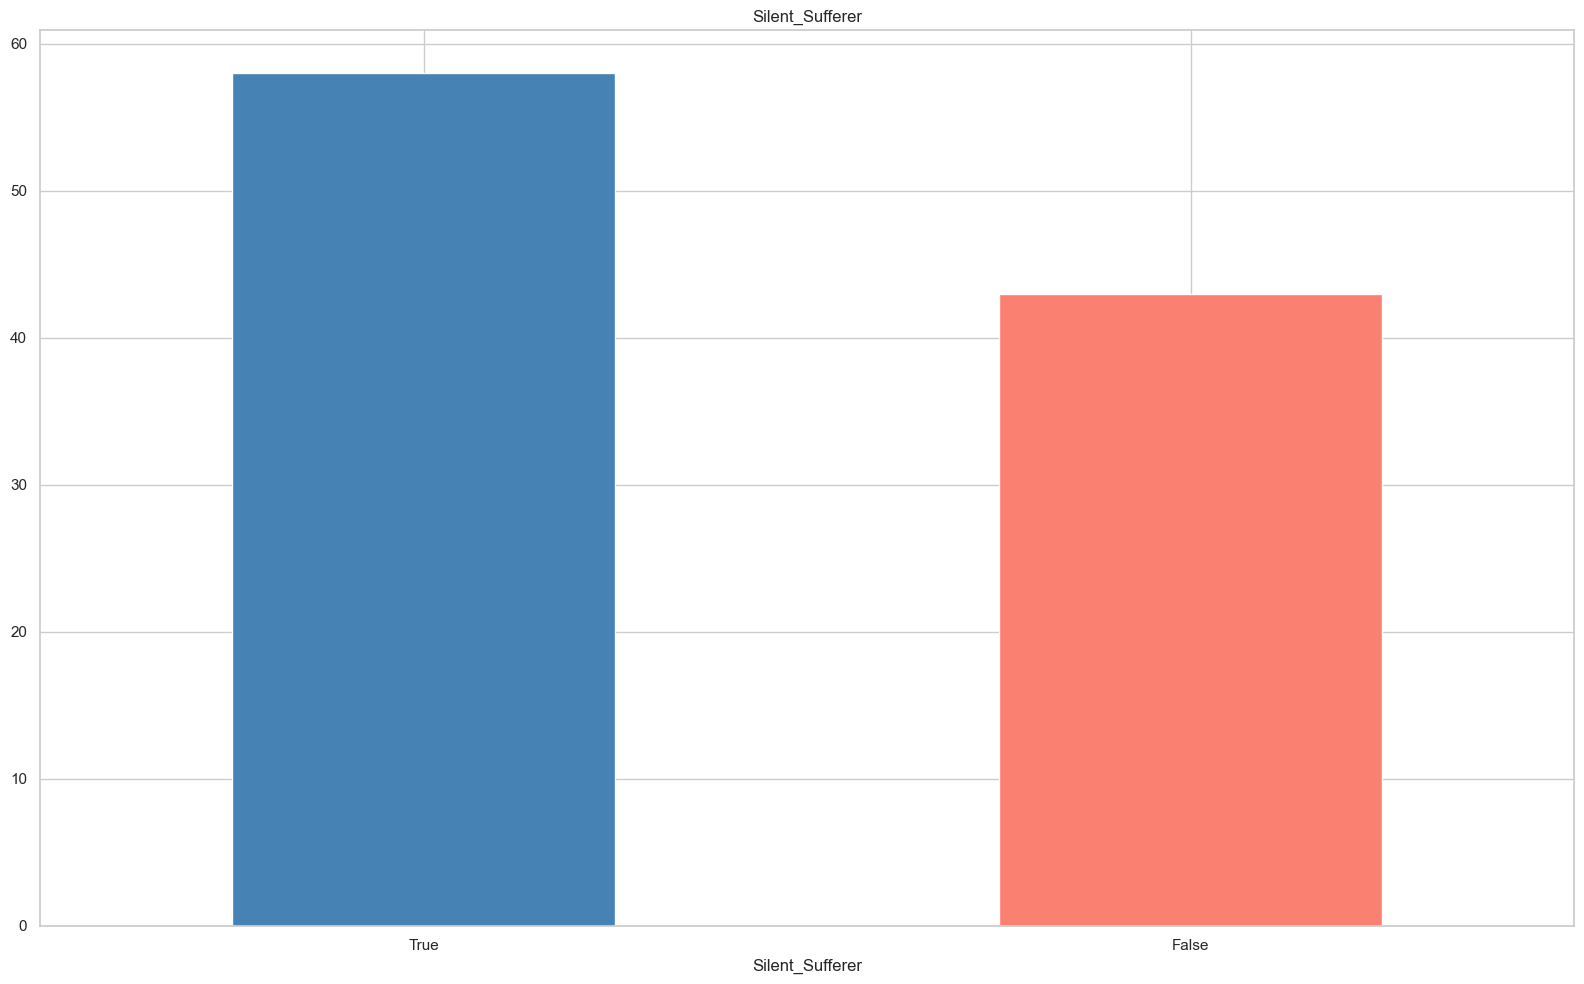

In [497]:
fig, axes = plt.subplots(1,1,figsize=(16, 10))

# Gender
df['Silent_Sufferer'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
axes.set_title('Silent_Sufferer')
axes.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show

In [498]:
def simplify_cgpa(cgpa):
    if cgpa in ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99']:
        return 'Below 3.00'
    return cgpa

df['CGPA_grouped'] = df['CGPA'].apply(simplify_cgpa)

df

,Gender,Age,Year,CGPA,Marital,Treatment,Any_condition,Course,Course_group,Risk_Level,Silent_Sufferer,CGPA_grouped
0,Female,18.0,1,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High,True,3.00 - 3.49
1,Male,21.0,2,3.00 - 3.49,No,No,True,Islamic Education,Humanities & Education,Medium,True,3.00 - 3.49
2,Male,19.0,1,3.00 - 3.49,No,No,True,BIT,Engineering & Computing,High,True,3.00 - 3.49
3,Female,22.0,3,3.00 - 3.49,Yes,No,True,Law,Humanities & Education,Medium,True,3.00 - 3.49
4,Male,23.0,4,3.00 - 3.49,No,No,False,Mathematics,Natural & Health Sciences,Low,False,3.00 - 3.49
...,...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,1,3.50 - 4.00,No,No,True,BCS,Engineering & Computing,Medium,True,3.50 - 4.00
97,Male,18.0,2,3.00 - 3.49,No,No,True,Engineering,Engineering & Computing,High,True,3.00 - 3.49
98,Female,19.0,3,3.50 - 4.00,Yes,No,True,Nursing,Natural & Health Sciences,High,True,3.50 - 4.00
99,Female,23.0,4,3.50 - 4.00,No,No,False,Islamic Education,Humanities & Education,Low,False,3.50 - 4.00


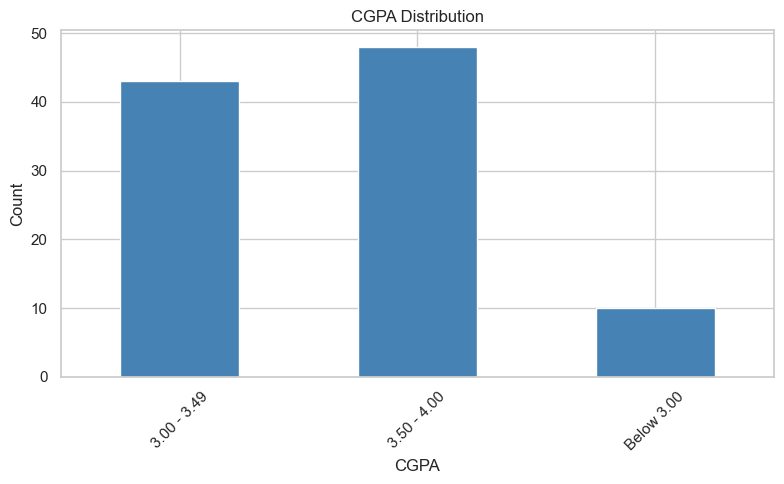

In [499]:
fig, ax = plt.subplots(figsize=(8, 5))

df['CGPA_grouped'].value_counts().sort_index().plot(
    kind='bar',
    ax=ax,
    color='steelblue'
)

ax.set_title('CGPA Distribution')
ax.set_xlabel('CGPA')
ax.set_ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [500]:
for col in ['Marital', 'Treatment']:
    df[col] = df[col].map({
        'Yes': True,
        'No': False
    })

In [501]:
df['Gender'] = df['Gender'].map({
    'Male': True,
    'Female': False
})

In [502]:
course_dummies = pd.get_dummies(df['Course_group'], prefix='CG', dtype=int)
df = pd.concat([df, course_dummies], axis=1)

In [503]:
df['CGPA_grouped'].unique()

<StringArray>
['3.00 - 3.49', '3.50 - 4.00', 'Below 3.00']
Length: 3, dtype: str

In [504]:
df['CGPA_grouped'] = pd.Categorical(
    df['CGPA_grouped'],
    categories=['Below 3.00', '3.00 - 3.49', '3.50 - 4.00'],
    ordered=True
)
df['CGPA_grouped_encoded'] = df['CGPA_grouped'].cat.codes

In [505]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Gender                        101 non-null    bool    
 1   Age                           101 non-null    float64 
 2   Year                          101 non-null    int64   
 3   CGPA                          101 non-null    str     
 4   Marital                       101 non-null    bool    
 5   Treatment                     101 non-null    bool    
 6   Any_condition                 101 non-null    bool    
 7   Course                        101 non-null    str     
 8   Course_group                  101 non-null    str     
 9   Risk_Level                    101 non-null    str     
 10  Silent_Sufferer               101 non-null    bool    
 11  CGPA_grouped                  101 non-null    category
 12  CG_Engineering & Computing    101 non-null    int64   
 13  C

In [506]:
df.drop(columns=['CGPA', 'Course', 'Treatment', 'Any_condition',
                 'Risk_Level', 'CGPA_grouped', 'Course_group'], inplace=True)
df

,Gender,Age,Year,Marital,Silent_Sufferer,CG_Engineering & Computing,CG_Humanities & Education,CG_Natural & Health Sciences,CG_Social Sciences,CGPA_grouped_encoded
0,False,18.0,1,False,True,1,0,0,0,1
1,True,21.0,2,False,True,0,1,0,0,1
2,True,19.0,1,False,True,1,0,0,0,1
3,False,22.0,3,True,True,0,1,0,0,1
4,True,23.0,4,False,False,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
96,False,21.0,1,False,True,1,0,0,0,2
97,True,18.0,2,False,True,1,0,0,0,1
98,False,19.0,3,True,True,0,0,1,0,2
99,False,23.0,4,False,False,0,1,0,0,2


Dapat disimpulkan bahwa disini kami memiliki 6 fitur dan 1 target, yakni
Fitur:
- Gender
- Age
- Year
- Marital
- Course_group
- CGPA_grouped_encoded

Target:
- Silent_Sufferer

## Feature Correlation

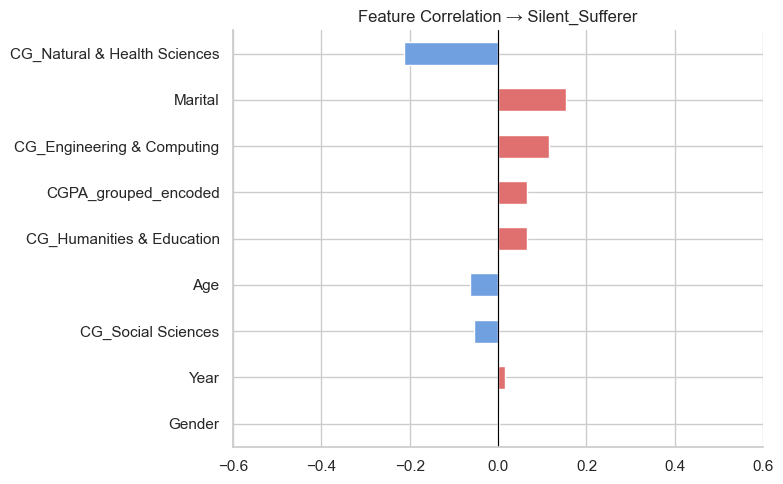

In [507]:
X = df.drop(columns=['Silent_Sufferer'])
y = df['Silent_Sufferer'].astype(int)

corrs = X.corrwith(y).sort_values(key=abs)
colors = ['#e07070' if v > 0 else '#70a0e0' for v in corrs]

fig, ax = plt.subplots(figsize=(8, 5))
corrs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation → Silent_Sufferer')
ax.set_xlim(-0.6, 0.6)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

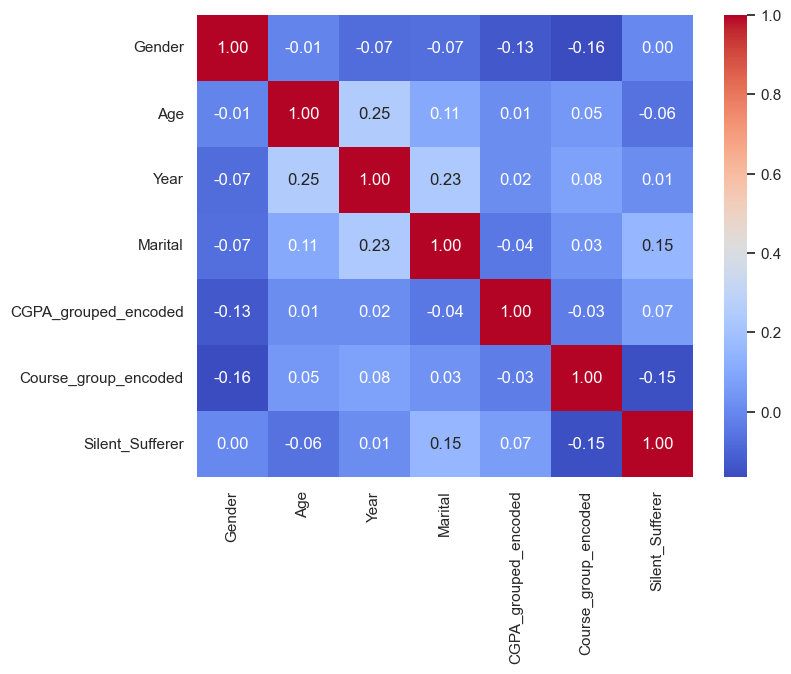

In [508]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = pd.concat(
    [features, targets['Silent_Sufferer']],
    axis=1
).corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.show()

# 2. Modeling

In [509]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              make_scorer, fbeta_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

X = df.drop(columns=['Silent_Sufferer'])
y = df['Silent_Sufferer'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

SCORING = {
    'accuracy' : 'accuracy',
    'f1'       : 'f1',
    'f1_macro' : 'f1_macro',
    'f2'       : make_scorer(fbeta_score, beta=2),
    'roc_auc'  : 'roc_auc',
}
METRICS = ['Accuracy', 'F1', 'F1 Macro', 'F2', 'ROC-AUC']

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Balance train: {y_train.value_counts().to_dict()}")

Train: 80 | Test: 21
Balance train: {1: 46, 0: 34}


In [510]:
def make_pipeline(name, model, smote=False):
    """Bungkus model dalam pipeline yang sesuai."""
    needs_scaling = name in ['SVM', 'KNN', 'Logistic Regression']

    if smote and needs_scaling:
        return ImbPipeline([
            ('smote',  SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('model',  model),
        ])
    elif smote:
        return ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', model),
        ])
    elif needs_scaling:
        return Pipeline([
            ('scaler', StandardScaler()),
            ('model',  model),
        ])
    else:
        return model


def run_cv(models_dict, X, y, cv, smote=False):
    """Jalankan cross-validation untuk semua model."""
    rows = []
    for name, model in models_dict.items():
        pipe = make_pipeline(name, model, smote=smote)
        scores = cross_validate(pipe, X, y, cv=cv, scoring=SCORING)
        rows.append({
            'Model'    : name,
            'Accuracy' : scores['test_accuracy'].mean(),
            'F1'       : scores['test_f1'].mean(),
            'F1 Macro' : scores['test_f1_macro'].mean(),
            'F2'       : scores['test_f2'].mean(),
            'ROC-AUC'  : scores['test_roc_auc'].mean(),
        })
    return pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)


def run_split(models_dict, X_train, y_train, X_test, y_test, smote=False):
    """Evaluasi dengan single train/test split."""
    from sklearn.metrics import accuracy_score, f1_score, fbeta_score, roc_auc_score
    if smote:
        X_tr, y_tr = SMOTE(random_state=42).fit_resample(X_train, y_train)
    else:
        X_tr, y_tr = X_train.copy(), y_train.copy()

    rows = []
    for name, model in models_dict.items():
        if name in ['SVM', 'KNN', 'Logistic Regression']:
            pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
        else:
            pipe = model
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:,1] if hasattr(pipe, 'predict_proba') else None
        rows.append({
            'Model'    : name,
            'Accuracy' : accuracy_score(y_test, y_pred),
            'F1'       : f1_score(y_test, y_pred),
            'F1 Macro' : f1_score(y_test, y_pred, average='macro'),
            'F2'       : fbeta_score(y_test, y_pred, beta=2),
            'ROC-AUC'  : roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        })
    return pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

In [511]:
models = {
    'Baseline'           : DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM'                : SVC(probability=True, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=42),
    'XGBoost'            : XGBClassifier(eval_metric='logloss', random_state=42),
}

In [512]:
results = {
    'Normal + Split'   : run_split(models, X_train, y_train, X_test, y_test, smote=False),
    'Normal + Strat-KF': run_cv(models, X, y, cv=skf,  smote=False),
    'SMOTE + Split'    : run_split(models, X_train, y_train, X_test, y_test, smote=True),
    'SMOTE + Strat-KF' : run_cv(models, X, y, cv=skf,  smote=True),
}

for strategy, df_res in results.items():
    print(f"\n{'='*60}")
    print(f"  {strategy}")
    print(f"{'='*60}")
    print(df_res[['Model'] + METRICS].round(3).to_string(index=False))


  Normal + Split
              Model  Accuracy    F1  F1 Macro    F2  ROC-AUC
      Random Forest     0.571 0.710     0.446 0.821    0.579
                KNN     0.571 0.690     0.499 0.769    0.574
  Gradient Boosting     0.619 0.714     0.571 0.781    0.542
            XGBoost     0.429 0.538     0.394 0.565    0.514
           Baseline     0.571 0.727     0.364 0.870    0.500
Logistic Regression     0.619 0.733     0.533 0.833    0.486
                SVM     0.619 0.750     0.475 0.882    0.403

  Normal + Strat-KF
              Model  Accuracy    F1  F1 Macro    F2  ROC-AUC
                SVM     0.603 0.719     0.508 0.815    0.532
      Random Forest     0.584 0.686     0.524 0.747    0.507
           Baseline     0.574 0.729     0.365 0.871    0.500
                KNN     0.484 0.587     0.436 0.623    0.495
Logistic Regression     0.593 0.702     0.526 0.773    0.455
            XGBoost     0.426 0.511     0.395 0.523    0.444
  Gradient Boosting     0.483 0.577     0.448 

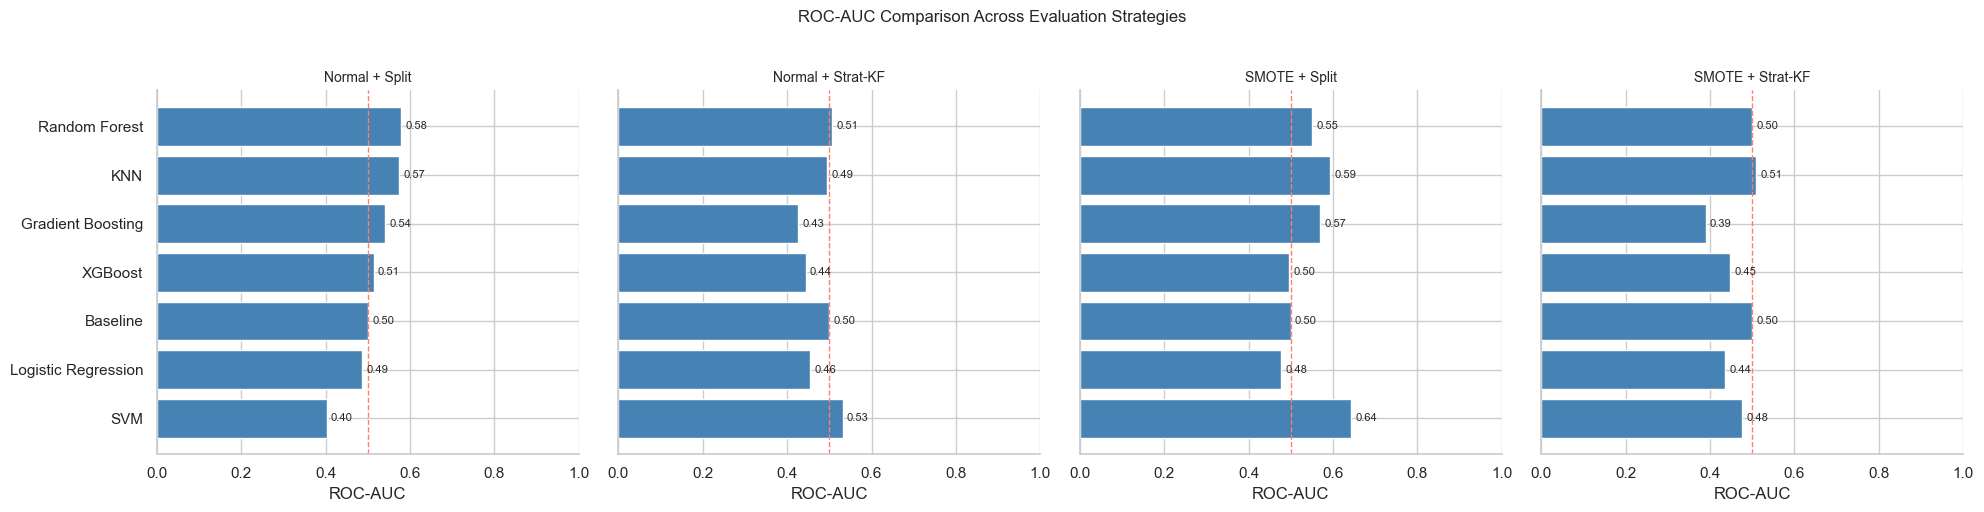

In [513]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, (strategy, df_res) in zip(axes, results.items()):
    df_plot = df_res.sort_values('ROC-AUC')
    bars = ax.barh(df_plot['Model'], df_plot['ROC-AUC'], color='steelblue')
    ax.axvline(0.5, color='salmon', linestyle='--', linewidth=1, label='Random')
    ax.set_xlim(0, 1)
    ax.set_title(strategy, fontsize=10)
    ax.set_xlabel('ROC-AUC')
    for bar, val in zip(bars, df_plot['ROC-AUC']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle('ROC-AUC Comparison Across Evaluation Strategies', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [514]:
for name, model in models.items():
    pipe = make_pipeline(name, model, smote=False)
    scores = cross_validate(pipe, X, y, cv=skf, scoring='roc_auc')
    mean = scores['test_score'].mean()
    std  = scores['test_score'].std()
    print(f"{name:<25} mean={mean:.3f}  std={std:.3f}  scores={np.round(scores['test_score'], 3)}")

Baseline                  mean=0.500  std=0.000  scores=[0.5 0.5 0.5 0.5 0.5]
Logistic Regression       mean=0.455  std=0.144  scores=[0.551 0.396 0.214 0.631 0.485]
SVM                       mean=0.532  std=0.116  scores=[0.671 0.542 0.339 0.621 0.485]
Random Forest             mean=0.507  std=0.121  scores=[0.671 0.458 0.307 0.53  0.566]
KNN                       mean=0.495  std=0.114  scores=[0.611 0.495 0.297 0.601 0.47 ]
Gradient Boosting         mean=0.425  std=0.135  scores=[0.634 0.365 0.234 0.389 0.505]
XGBoost                   mean=0.444  std=0.095  scores=[0.449 0.448 0.286 0.449 0.586]
